In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm as tqdm

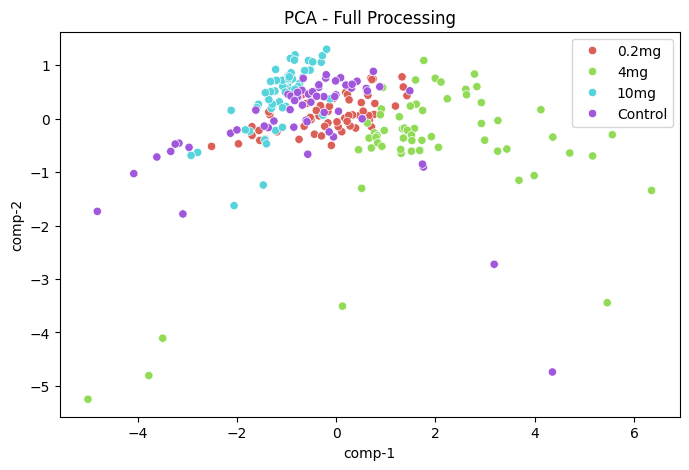

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import svm
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

#read the data
data = pd.read_excel('./Combined_Preprocessing.xlsx')
X_features = data.iloc[:, 1:1301]
y_label = data.iloc[:,0]

#convert the features into the 2 top features
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(X_features)
#principalDf = pd.DataFrame(data = principalComponents, columns =['principal component 1', 'principal component 2'])
#principalDf.head(5)
#data[['group']].head()
#finalDf = pd.concat([principalDf, data[['group']]], axis = 1)
df = pd.DataFrame()
df["y"] = y_label
df["comp-1"] = principalComponents[:,0]
df["comp-2"] = principalComponents[:,1]
scatter_plot = sns.scatterplot(x="comp-1", y="comp-2", hue=df.y.tolist(),
palette=sns.color_palette("hls", 4),data=df).set(title="PCA - Full Processing")
#plt.savefig('PCA – No Processing.png')

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 241 samples in 0.002s...
[t-SNE] Computed neighbors for 241 samples in 0.006s...
[t-SNE] Computed conditional probabilities for sample 241 / 241
[t-SNE] Mean sigma: 8689.069949
[t-SNE] KL divergence after 250 iterations with early exaggeration: 44.664158
[t-SNE] KL divergence after 1000 iterations: 0.164388


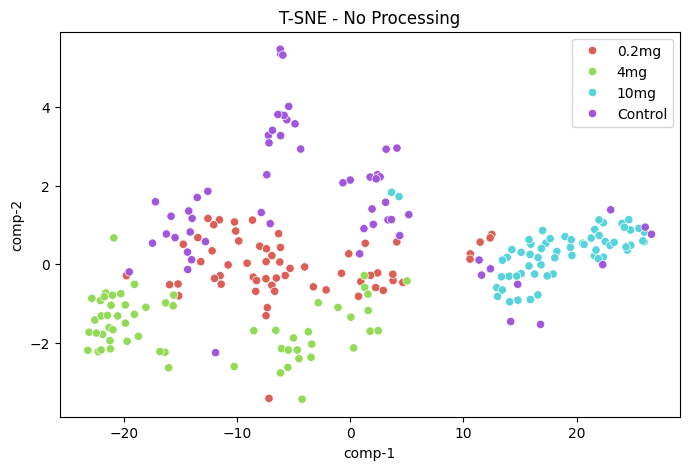

In [8]:
#t-SNE
from sklearn.manifold import TSNE
from numpy import reshape
import seaborn as sns

tsne = TSNE(n_components=2, verbose=1, random_state=123)
z = tsne.fit_transform(X_features)
df = pd.DataFrame()
df["y"] = y_label
df["comp-1"] = z[:,0]
df["comp-2"] = z[:,1]
scatter_plot = sns.scatterplot(x="comp-1", y="comp-2", hue=df.y.tolist(),
palette=sns.color_palette("hls", 4),
data=df).set(title="T-SNE - No Processing")

Calculating PHATE...
  Running PHATE on 241 observations and 1300 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 0.03 seconds.
    Calculating KNN search...
    Calculating affinities...
  Calculated graph and diffusion operator in 0.04 seconds.
  Calculating diffusion potential...
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by 1.9% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 0.13 seconds.
Calculated PHATE in 0.18 seconds.


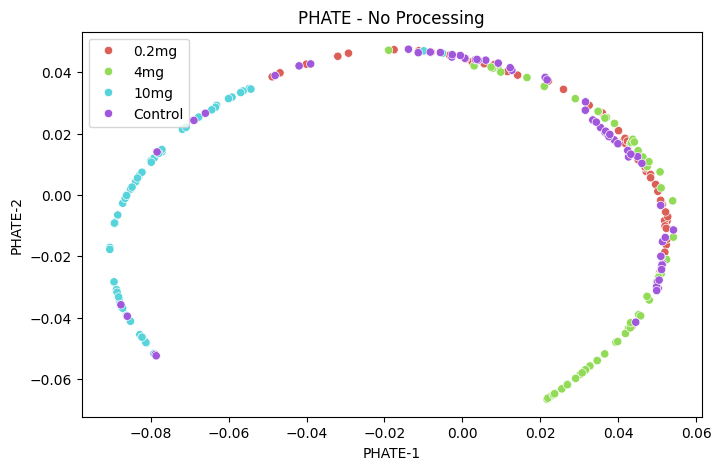

In [9]:
#phate
import phate
phate_op = phate.PHATE()
phate_op.set_params(knn=10, decay=15, t=12)#knn : Number of nearest neighbors (default: 5).
#Increase this (e.g. to 20) if your PHATE embedding appears verydisconnected.
#You should also consider increasing knn if your dataset is extremely large(e.g. >100k cells)
#decay : Alpha decay (default: 15). Decreasing decay increases connectivity on the graph,
#increasing decay decreases connectivity.
#This rarely needs to be tuned. Set it to None for a k-nearest neighbors kernel.

data_phate = phate_op.fit_transform(X_features)
result_phate = pd.DataFrame()
result_phate["y"] = y_label
result_phate["PHATE-1"] = data_phate[:,0]
result_phate["PHATE-2"] = data_phate[:,1]
sns.scatterplot(x="PHATE-1", y="PHATE-2", hue=result_phate.y.tolist(),
palette=sns.color_palette("hls", 4),data=result_phate).set(title="PHATE - No Processing")
plt.savefig('PHATE – No Processing.png')

[Text(0.5, 1.0, 'UMAP No Processing')]

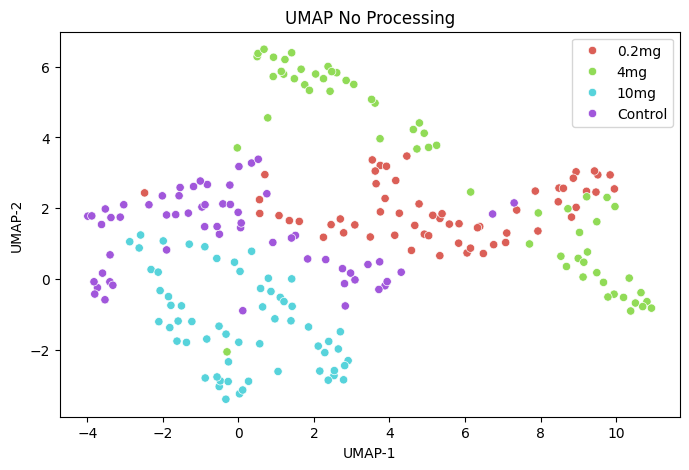

In [10]:
#UMAP
from numpy import reshape
import seaborn as sns
import umap
# import umap.plot

plt.rcParams['figure.figsize'] = (8,5)
#mapper = umap.UMAP().fit(X_features)
#umap.plot.points(mapper, labels=y_label)
embedding = umap.UMAP(n_neighbors=10,
min_dist=0.5,n_components=2,
metric='correlation').fit_transform(X_features)
result = pd.DataFrame()
result["y"] = y_label
result["UMAP-1"] = embedding[:,0]
result["UMAP-2"] = embedding[:,1]
sns.scatterplot(x="UMAP-1", y="UMAP-2", hue=result.y.tolist(),
palette=sns.color_palette("hls", 4),
data=result).set(title="UMAP No Processing")